# Evaluation analysis by density and noise

Compare CPSAM v2 and NanoVision object- and pixel-level evaluation results on the test split.

In [4]:
from pathlib import Path


PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").is_file()
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CPSAM_EVALUATION_DIR = (
    PROJECT_ROOT
    / "global_outputs"
    / "evaluations"
    / "cpsam_v2_all_thresholds_unfiltered"
)

NANOVISION_EVALUATION_DIR = (
    PROJECT_ROOT
    / "global_outputs"
    / "evaluations"
    / "nanovision_all_thresholds_unfiltered"
)

print("Current directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print(
    "CPSAM exists:",
    CPSAM_EVALUATION_DIR.is_dir(),
)
print(
    "NanoVision exists:",
    NANOVISION_EVALUATION_DIR.is_dir(),
)

Current directory: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\stratified_evaluation
Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
CPSAM exists: True
NanoVision exists: True


In [5]:
cpsam_object = pd.read_csv(
    CPSAM_EVALUATION_DIR
    / "object_metrics_per_image_threshold.csv"
)

nanovision_object = pd.read_csv(
    NANOVISION_EVALUATION_DIR
    / "object_metrics_per_image_threshold.csv"
)

cpsam_pixel = pd.read_csv(
    CPSAM_EVALUATION_DIR
    / "pixel_metrics_per_image.csv"
)

nanovision_pixel = pd.read_csv(
    NANOVISION_EVALUATION_DIR
    / "pixel_metrics_per_image.csv"
)

cpsam_object["model"] = "CPSAM v2"
nanovision_object["model"] = "NanoVision"

cpsam_pixel["model"] = "CPSAM v2"
nanovision_pixel["model"] = "NanoVision"

# # combine both 

In [6]:
object_results = pd.concat(
    [
        cpsam_object,
        nanovision_object,
    ],
    ignore_index=True,
)

pixel_results = pd.concat(
    [
        cpsam_pixel,
        nanovision_pixel,
    ],
    ignore_index=True,
)

print("Object rows:", len(object_results))
print("Pixel rows:", len(pixel_results))

display(object_results.head())
display(pixel_results.head())

Object rows: 1800
Pixel rows: 60


,filename,matching_metric,threshold,num_gt_objects,num_pred_objects,true_positives,false_positives,false_negatives,precision,recall,f1_score,dsb_precision,matched_feature_pair_count,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter,model
0,1293-22_3_2_20230306222551.tif,iou,0.1,104,116,96,20,8,0.827586,0.923077,0.872727,0.774194,96,0.198692,0.336311,5.194917,116,0,CPSAM v2
1,1293-22_3_2_20230306222551.tif,iou,0.2,104,116,95,21,9,0.818966,0.913462,0.863636,0.760000,95,0.176530,0.277585,4.434982,116,0,CPSAM v2
2,1293-22_3_2_20230306222551.tif,iou,0.3,104,116,88,28,16,0.758621,0.846154,0.800000,0.666667,88,0.141624,0.228069,3.502772,116,0,CPSAM v2
3,1293-22_3_2_20230306222551.tif,iou,0.4,104,116,69,47,35,0.594828,0.663462,0.627273,0.456954,69,0.086118,0.169829,2.658226,116,0,CPSAM v2
4,1293-22_3_2_20230306222551.tif,iou,0.5,104,116,45,71,59,0.387931,0.432692,0.409091,0.257143,45,0.062295,0.123896,2.111226,116,0,CPSAM v2


,filename,num_gt_objects,num_pred_objects,true_positive_pixels,false_positive_pixels,false_negative_pixels,true_negative_pixels,pixel_precision,pixel_recall,pixel_f1,pixel_fdr,pixel_iou,pixel_dice,pixel_cldice,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter,model
0,1293-22_3_2_20230306222551.tif,104,116,7803,7307,865,49561,0.516413,0.900208,0.656321,0.483587,0.488451,0.656321,0.828847,116,0,CPSAM v2
1,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,163,168,15813,5793,1105,42825,0.731880,0.934685,0.820943,0.268120,0.696271,0.820943,0.932323,168,0,CPSAM v2
2,400-1093-w11-c1p2-befo3-20sp-15flow_left.tif,241,250,22164,7998,1051,34323,0.734832,0.954728,0.830470,0.265168,0.710089,0.830470,0.922015,250,0,CPSAM v2
3,400-1093-w13-c1-p1-10sp-15flow_left.tif,131,125,13242,2493,819,48982,0.841563,0.941754,0.888844,0.158437,0.799928,0.888844,0.968674,125,0,CPSAM v2
4,400-1093-w16-c-1-p1-10sp-15flow_left.tif,219,226,20645,6266,1611,37014,0.767158,0.927615,0.839791,0.232842,0.723827,0.839791,0.933658,226,0,CPSAM v2


In [7]:
print("Object columns:")
print(object_results.columns.tolist())

print()
print("Pixel columns:")
print(pixel_results.columns.tolist())

print()
print(
    "Images per model:",
    pixel_results.groupby("model")["filename"].nunique(),
)

Object columns:
['filename', 'matching_metric', 'threshold', 'num_gt_objects', 'num_pred_objects', 'true_positives', 'false_positives', 'false_negatives', 'precision', 'recall', 'f1_score', 'dsb_precision', 'matched_feature_pair_count', 'mean_absolute_length_error_um', 'mean_absolute_relative_length_error', 'mean_absolute_orientation_error_deg', 'num_pred_objects_before_endpoint_filter', 'num_pred_objects_rejected_by_endpoint_filter', 'model']

Pixel columns:
['filename', 'num_gt_objects', 'num_pred_objects', 'true_positive_pixels', 'false_positive_pixels', 'false_negative_pixels', 'true_negative_pixels', 'pixel_precision', 'pixel_recall', 'pixel_f1', 'pixel_fdr', 'pixel_iou', 'pixel_dice', 'pixel_cldice', 'num_pred_objects_before_endpoint_filter', 'num_pred_objects_rejected_by_endpoint_filter', 'model']

Images per model: model
CPSAM v2      30
NanoVision    30
Name: filename, dtype: int64


In [8]:
SPLIT_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "splits"
    / "legacy_dataloader_seed_42.csv"
)

DENSITY_METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "metadata"
    / "density_classified_filenames.csv"
)

NOISE_METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "metadata"
    / "noise_classification.csv"
)

split_manifest = pd.read_csv(
    SPLIT_MANIFEST_PATH
)

density_metadata = pd.read_csv(
    DENSITY_METADATA_PATH
)

noise_metadata = pd.read_csv(
    NOISE_METADATA_PATH
)

In [9]:
print(
    "Split manifest:",
    split_manifest.shape,
    split_manifest.columns.tolist(),
)

print(
    "Density metadata:",
    density_metadata.shape,
    density_metadata.columns.tolist(),
)

print(
    "Noise metadata:",
    noise_metadata.shape,
    noise_metadata.columns.tolist(),
)

display(split_manifest.head())
display(density_metadata.head())
display(noise_metadata.head())

Split manifest: (130, 6) ['filename', 'subset', 'gt_object_count', 'density_class', 'noise_sigma', 'noise_class']
Density metadata: (130, 5) ['filename', 'gt_object_count', 'density_class_tertile', 'density_class_kmeans', 'density_class']
Noise metadata: (130, 5) ['filename', 'noise_sigma', 'noise_class_otsu', 'noise_class_kmeans', 'noise_class']


,filename,subset,gt_object_count,density_class,noise_sigma,noise_class
0,1293-22_3_-2_20230306230321.tif,train,112,High,25.203849,Noisy
1,1293-22_3_0_20230306224436.tif,train,96,High,24.462573,Noisy
2,1293-22_3_2_20230306222551.tif,test,104,High,28.169017,Noisy
3,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,test,163,High,5.189029,Clean
4,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,val,167,High,5.189030,Clean


,filename,gt_object_count,density_class_tertile,density_class_kmeans,density_class
0,1293-22_3_-2_20230306230321.tif,112,High,Mid,High
1,1293-22_3_0_20230306224436.tif,96,High,Mid,High
2,1293-22_3_2_20230306222551.tif,104,High,Mid,High
3,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,163,High,Mid,High
4,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,167,High,Mid,High


,filename,noise_sigma,noise_class_otsu,noise_class_kmeans,noise_class
0,1293-22_3_-2_20230306230321.tif,25.203849,Noisy,Noisy,Noisy
1,1293-22_3_0_20230306224436.tif,24.462573,Noisy,Noisy,Noisy
2,1293-22_3_2_20230306222551.tif,28.169017,Noisy,Noisy,Noisy
3,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,5.189029,Clean,Clean,Clean
4,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,5.189030,Clean,Clean,Clean


# # Select test-image metadata

In [10]:
test_metadata = (
    split_manifest.loc[
        split_manifest["subset"] == "test",
        [
            "filename",
            "gt_object_count",
            "density_class",
            "noise_sigma",
            "noise_class",
        ],
    ]
    .copy()
)

print("Test images:", len(test_metadata))

display(test_metadata.head())

Test images: 30


,filename,gt_object_count,density_class,noise_sigma,noise_class
2,1293-22_3_2_20230306222551.tif,104,High,28.169017,Noisy
3,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,163,High,5.189029,Clean
5,400-1093-w11-c1p2-befo3-20sp-15flow_left.tif,241,High,6.671608,Clean
7,400-1093-w13-c1-p1-10sp-15flow_left.tif,131,High,6.671611,Clean
10,400-1093-w16-c-1-p1-10sp-15flow_left.tif,219,High,8.154188,Clean


# # Merge metadata into evaluation results

In [11]:
object_results = object_results.merge(
    test_metadata,
    on="filename",
    how="left",
    validate="many_to_one",
)

pixel_results = pixel_results.merge(
    test_metadata,
    on="filename",
    how="left",
    validate="many_to_one",
)

# # Verify that every image matched

In [12]:
print(
    "Object rows without metadata:",
    object_results["density_class"].isna().sum(),
)

print(
    "Pixel rows without metadata:",
    pixel_results["density_class"].isna().sum(),
)

assert not object_results[
    "density_class"
].isna().any()

assert not pixel_results[
    "density_class"
].isna().any()

print("PASS: all evaluation images matched metadata.")

Object rows without metadata: 0
Pixel rows without metadata: 0
PASS: all evaluation images matched metadata.


In [13]:
object_results

,filename,matching_metric,threshold,num_gt_objects,num_pred_objects,true_positives,false_positives,false_negatives,precision,recall,...,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter,model,gt_object_count,density_class,noise_sigma,noise_class
0,1293-22_3_2_20230306222551.tif,iou,0.1,104,116,96,20,8,0.827586,0.923077,...,0.198692,0.336311,5.194917,116,0,CPSAM v2,104,High,28.169017,Noisy
1,1293-22_3_2_20230306222551.tif,iou,0.2,104,116,95,21,9,0.818966,0.913462,...,0.176530,0.277585,4.434982,116,0,CPSAM v2,104,High,28.169017,Noisy
2,1293-22_3_2_20230306222551.tif,iou,0.3,104,116,88,28,16,0.758621,0.846154,...,0.141624,0.228069,3.502772,116,0,CPSAM v2,104,High,28.169017,Noisy
3,1293-22_3_2_20230306222551.tif,iou,0.4,104,116,69,47,35,0.594828,0.663462,...,0.086118,0.169829,2.658226,116,0,CPSAM v2,104,High,28.169017,Noisy
4,1293-22_3_2_20230306222551.tif,iou,0.5,104,116,45,71,59,0.387931,0.432692,...,0.062295,0.123896,2.111226,116,0,CPSAM v2,104,High,28.169017,Noisy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,400-1605-W8_map_00049_top_right.tif,centerline_chamfer_gt_width,0.6,58,69,33,36,25,0.478261,0.568966,...,0.072763,0.177661,1.950247,69,0,NanoVision,58,Mid,17.049661,Noisy
1796,400-1605-W8_map_00049_top_right.tif,centerline_chamfer_gt_width,0.7,58,69,39,30,19,0.565217,0.672414,...,0.092468,0.216160,3.169515,69,0,NanoVision,58,Mid,17.049661,Noisy
1797,400-1605-W8_map_00049_top_right.tif,centerline_chamfer_gt_width,0.8,58,69,40,29,18,0.579710,0.689655,...,0.096371,0.218994,3.207412,69,0,NanoVision,58,Mid,17.049661,Noisy
1798,400-1605-W8_map_00049_top_right.tif,centerline_chamfer_gt_width,0.9,58,69,40,29,18,0.579710,0.689655,...,0.096371,0.218994,3.207412,69,0,NanoVision,58,Mid,17.049661,Noisy


# # Inspect test-set composition

In [14]:
density_counts = (
    test_metadata["density_class"]
    .value_counts()
    .sort_index()
)

noise_counts = (
    test_metadata["noise_class"]
    .value_counts()
    .sort_index()
)

print("Density:")
display(density_counts)

print("Noise:")
display(noise_counts)

Density:


density_class
High    12
Low      7
Mid     11
Name: count, dtype: int64

Noise:


noise_class
Clean    20
Noisy    10
Name: count, dtype: int64

In [15]:
display(
    pd.crosstab(
        test_metadata["density_class"],
        test_metadata["noise_class"],
        margins=True,
    )
)

noise_class,Clean,Noisy,All
density_class,,,
High,9,3,12
Low,5,2,7
Mid,6,5,11
All,20,10,30


# # Object metrics by density

In [16]:
object_by_density = (
    object_results.groupby(
        [
            "model",
            "density_class",
            "matching_metric",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "filename",
            "nunique",
        ),
        mean_precision=(
            "precision",
            "mean",
        ),
        mean_recall=(
            "recall",
            "mean",
        ),
        mean_f1=(
            "f1_score",
            "mean",
        ),
        mean_dsb_precision=(
            "dsb_precision",
            "mean",
        ),
        mean_length_error_um=(
            "mean_absolute_length_error_um",
            "mean",
        ),
        mean_relative_length_error=(
            "mean_absolute_relative_length_error",
            "mean",
        ),
        mean_orientation_error_deg=(
            "mean_absolute_orientation_error_deg",
            "mean",
        ),
    )
)

display(object_by_density)

,model,density_class,matching_metric,threshold,number_of_images,mean_precision,mean_recall,mean_f1,mean_dsb_precision,mean_length_error_um,mean_relative_length_error,mean_orientation_error_deg
0,CPSAM v2,High,centerline_chamfer_gt_width,0.1,12,0.095939,0.094173,0.094982,0.051232,0.033874,0.109227,2.040841
1,CPSAM v2,High,centerline_chamfer_gt_width,0.2,12,0.387652,0.381164,0.384022,0.250002,0.040887,0.108075,1.968136
2,CPSAM v2,High,centerline_chamfer_gt_width,0.3,12,0.534744,0.526929,0.530290,0.377627,0.046507,0.117478,2.364392
3,CPSAM v2,High,centerline_chamfer_gt_width,0.4,12,0.618247,0.609793,0.613373,0.458199,0.052127,0.133632,2.731259
4,CPSAM v2,High,centerline_chamfer_gt_width,0.5,12,0.675818,0.666378,0.670345,0.518925,0.059290,0.145534,3.034797
...,...,...,...,...,...,...,...,...,...,...,...,...
175,NanoVision,Mid,iou,0.6,11,0.245655,0.320544,0.276054,0.165144,0.051725,0.105837,1.587047
176,NanoVision,Mid,iou,0.7,11,0.088025,0.110644,0.097440,0.052968,0.031914,0.075686,1.312528
177,NanoVision,Mid,iou,0.8,11,0.011005,0.013682,0.012149,0.006159,0.041387,0.126949,2.194724
178,NanoVision,Mid,iou,0.9,11,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN


# # Object metrics by noise

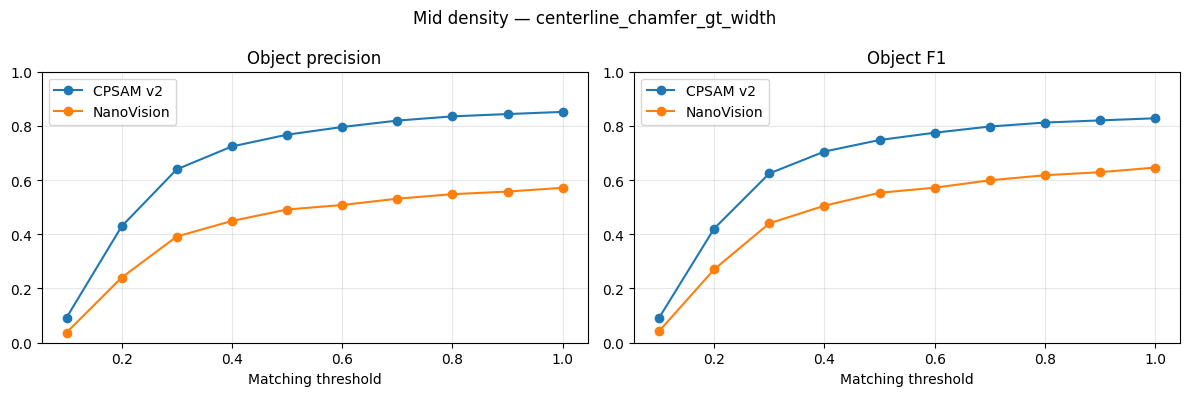

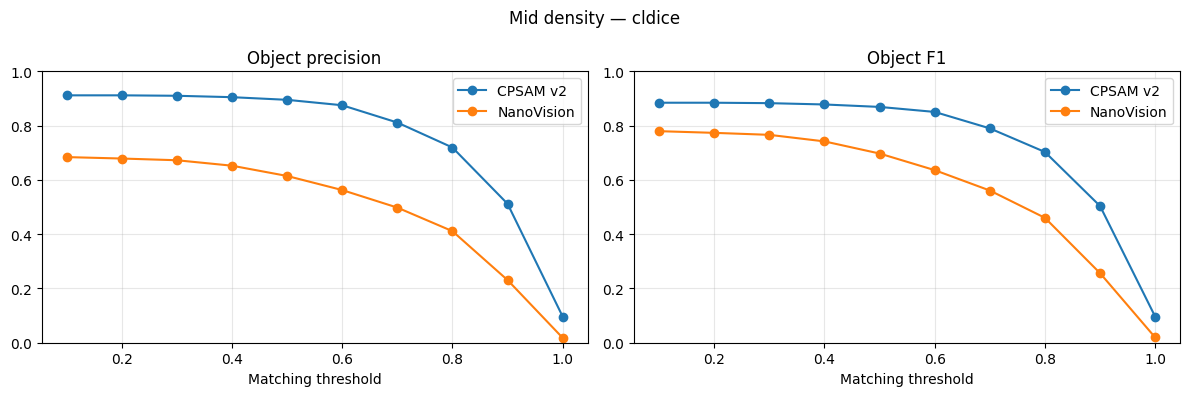

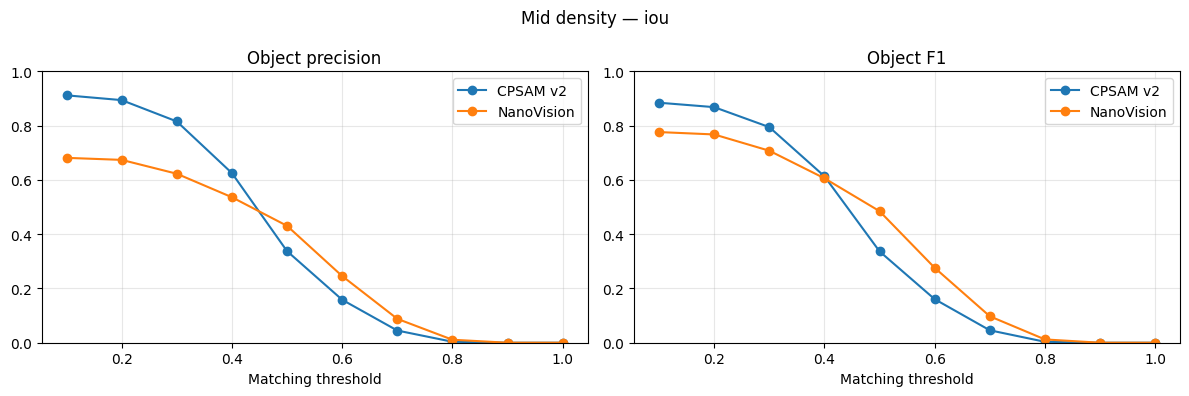

In [28]:
density_class = "Mid"

for matching_metric in (
    object_by_density["matching_metric"].unique()
):
    subset = object_by_density[
        (
            object_by_density["density_class"]
            == density_class
        )
        & (
            object_by_density["matching_metric"]
            == matching_metric
        )
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
    )

    for model, model_data in subset.groupby(
        "model"
    ):
        model_data = model_data.sort_values(
            "threshold"
        )

        axes[0].plot(
            model_data["threshold"],
            model_data["mean_precision"],
            marker="o",
            label=model,
        )

        axes[1].plot(
            model_data["threshold"],
            model_data["mean_f1"],
            marker="o",
            label=model,
        )

    axes[0].set_title("Object precision")
    axes[1].set_title("Object F1")

    for axis in axes:
        axis.set_xlabel("Matching threshold")
        axis.set_ylim(0.0, 1.0)
        axis.grid(
            alpha=0.3
        )
        axis.legend()

    fig.suptitle(
        f"{density_class} density — "
        f"{matching_metric}"
    )

    fig.tight_layout()
    plt.show()

# # Performances for (density, noise)

In [18]:
object_by_density_noise = (
    object_results.groupby(
        [
            "model",
            "noise_class",
            "density_class",
            "matching_metric",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "filename",
            "nunique",
        ),
        mean_precision=(
            "precision",
            "mean",
        ),
        mean_recall=(
            "recall",
            "mean",
        ),
        mean_f1=(
            "f1_score",
            "mean",
        ),
        mean_dsb_precision=(
            "dsb_precision",
            "mean",
        ),
        mean_length_error_um=(
            "mean_absolute_length_error_um",
            "mean",
        ),
        mean_relative_length_error=(
            "mean_absolute_relative_length_error",
            "mean",
        ),
        mean_orientation_error_deg=(
            "mean_absolute_orientation_error_deg",
            "mean",
        ),
    )
)

display(object_by_density_noise)

,model,noise_class,density_class,matching_metric,threshold,number_of_images,mean_precision,mean_recall,mean_f1,mean_dsb_precision,mean_length_error_um,mean_relative_length_error,mean_orientation_error_deg
0,CPSAM v2,Clean,High,centerline_chamfer_gt_width,0.1,9,0.113814,0.112394,0.113044,0.061306,0.029812,0.080378,1.870317
1,CPSAM v2,Clean,High,centerline_chamfer_gt_width,0.2,9,0.421562,0.416570,0.418832,0.277616,0.035515,0.097626,2.125761
2,CPSAM v2,Clean,High,centerline_chamfer_gt_width,0.3,9,0.560998,0.554018,0.557177,0.405479,0.042005,0.113231,2.608479
3,CPSAM v2,Clean,High,centerline_chamfer_gt_width,0.4,9,0.632306,0.623892,0.627711,0.476840,0.047436,0.130183,2.970779
4,CPSAM v2,Clean,High,centerline_chamfer_gt_width,0.5,9,0.681382,0.671723,0.676115,0.529152,0.053933,0.140382,3.367802
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,NanoVision,Noisy,Mid,iou,0.6,5,0.204659,0.282539,0.236317,0.137421,0.044743,0.098436,1.062764
356,NanoVision,Noisy,Mid,iou,0.7,5,0.069383,0.094646,0.079827,0.042802,0.028922,0.066590,0.872088
357,NanoVision,Noisy,Mid,iou,0.8,5,0.011728,0.016085,0.013548,0.006878,0.048642,0.137231,0.734070
358,NanoVision,Noisy,Mid,iou,0.9,5,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN


In [19]:
object_by_density_noise = (
    object_results
    .groupby(
        [
            "model",
            "density_class",
            "noise_class",
            "matching_metric",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=("filename", "nunique"),
        mean_precision=("precision", "mean"),
        mean_f1=("f1_score", "mean"),
    )
)

display(object_by_density_noise.head())

,model,density_class,noise_class,matching_metric,threshold,number_of_images,mean_precision,mean_f1
0,CPSAM v2,High,Clean,centerline_chamfer_gt_width,0.1,9,0.113814,0.113044
1,CPSAM v2,High,Clean,centerline_chamfer_gt_width,0.2,9,0.421562,0.418832
2,CPSAM v2,High,Clean,centerline_chamfer_gt_width,0.3,9,0.560998,0.557177
3,CPSAM v2,High,Clean,centerline_chamfer_gt_width,0.4,9,0.632306,0.627711
4,CPSAM v2,High,Clean,centerline_chamfer_gt_width,0.5,9,0.681382,0.676115


Images in this category: 9


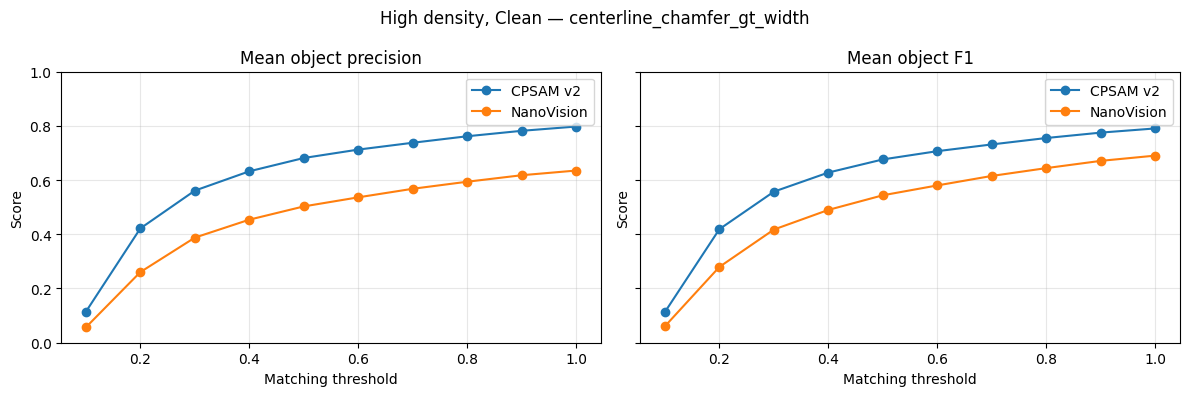

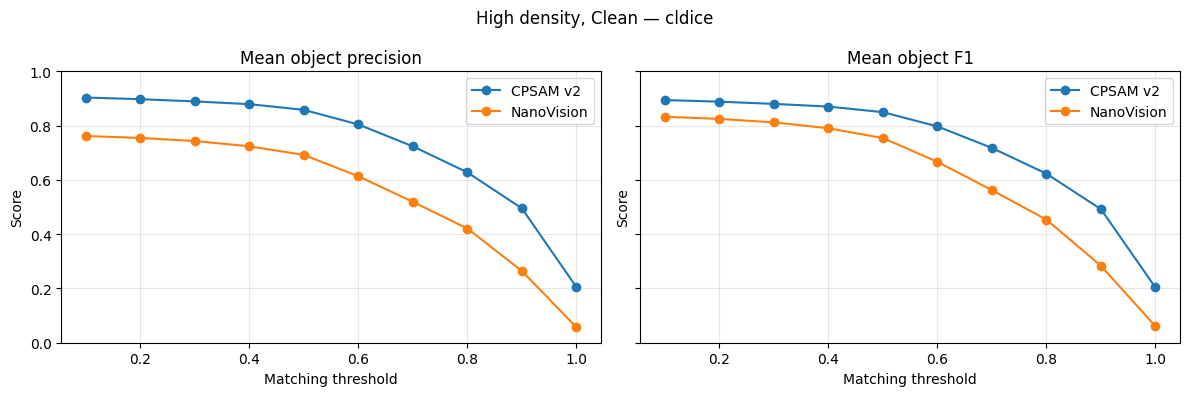

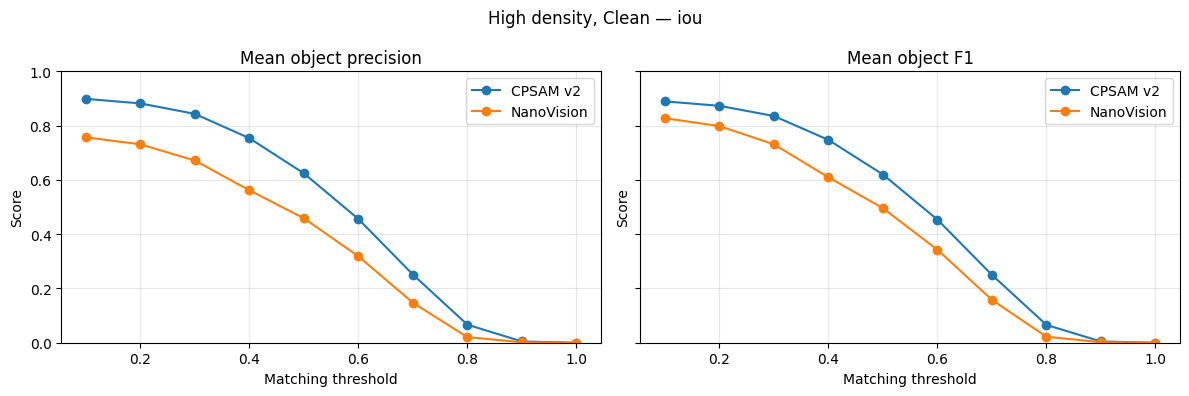

In [20]:
density_class = "High"
noise_class = "Clean"

selected = object_by_density_noise[
    (
        object_by_density_noise["density_class"]
        == density_class
    )
    & (
        object_by_density_noise["noise_class"]
        == noise_class
    )
]

print(
    "Images in this category:",
    test_metadata[
        (
            test_metadata["density_class"]
            == density_class
        )
        & (
            test_metadata["noise_class"]
            == noise_class
        )
    ]["filename"].nunique(),
)

for matching_metric in selected[
    "matching_metric"
].unique():
    subset = selected[
        selected["matching_metric"]
        == matching_metric
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
        sharey=True,
    )

    for model, model_data in subset.groupby(
        "model"
    ):
        model_data = model_data.sort_values(
            "threshold"
        )

        axes[0].plot(
            model_data["threshold"],
            model_data["mean_precision"],
            marker="o",
            label=model,
        )

        axes[1].plot(
            model_data["threshold"],
            model_data["mean_f1"],
            marker="o",
            label=model,
        )

    axes[0].set_title("Mean object precision")
    axes[1].set_title("Mean object F1")

    for axis in axes:
        axis.set_xlabel("Matching threshold")
        axis.set_ylabel("Score")
        axis.set_ylim(0.0, 1.0)
        axis.grid(alpha=0.3)
        axis.legend()

    fig.suptitle(
        f"{density_class} density, "
        f"{noise_class} — {matching_metric}"
    )

    fig.tight_layout()
    plt.show()

# # Mean F1 and DSB mAP over all thresholds by density

In [21]:
object_by_noise = (
    object_results.groupby(
        [
            "model",
            "noise_class",
            "matching_metric",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "filename",
            "nunique",
        ),
        mean_precision=(
            "precision",
            "mean",
        ),
        mean_recall=(
            "recall",
            "mean",
        ),
        mean_f1=(
            "f1_score",
            "mean",
        ),
        mean_dsb_precision=(
            "dsb_precision",
            "mean",
        ),
        mean_length_error_um=(
            "mean_absolute_length_error_um",
            "mean",
        ),
        mean_relative_length_error=(
            "mean_absolute_relative_length_error",
            "mean",
        ),
        mean_orientation_error_deg=(
            "mean_absolute_orientation_error_deg",
            "mean",
        ),
    )
)

display(object_by_noise)

,model,noise_class,matching_metric,threshold,number_of_images,mean_precision,mean_recall,mean_f1,mean_dsb_precision,mean_length_error_um,mean_relative_length_error,mean_orientation_error_deg
0,CPSAM v2,Clean,centerline_chamfer_gt_width,0.1,20,0.106479,0.109790,0.107776,0.058374,0.039259,0.104022,1.654330
1,CPSAM v2,Clean,centerline_chamfer_gt_width,0.2,20,0.438362,0.456897,0.445048,0.294542,0.048958,0.121462,1.924051
2,CPSAM v2,Clean,centerline_chamfer_gt_width,0.3,20,0.600320,0.623249,0.608283,0.449536,0.055305,0.138304,2.388377
3,CPSAM v2,Clean,centerline_chamfer_gt_width,0.4,20,0.670768,0.694424,0.678758,0.526785,0.060467,0.150871,2.677989
4,CPSAM v2,Clean,centerline_chamfer_gt_width,0.5,20,0.717204,0.741218,0.725201,0.581961,0.066045,0.160055,2.900932
...,...,...,...,...,...,...,...,...,...,...,...,...
115,NanoVision,Noisy,iou,0.6,10,0.261511,0.332826,0.290281,0.192265,0.040991,0.083390,3.185062
116,NanoVision,Noisy,iou,0.7,10,0.098490,0.118059,0.106586,0.061249,0.031472,0.070192,1.402935
117,NanoVision,Noisy,iou,0.8,10,0.007027,0.009431,0.008040,0.004076,0.046247,0.134174,0.582997
118,NanoVision,Noisy,iou,0.9,10,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN


In [22]:
object_map_by_density = (
    object_by_density.groupby(
        [
            "model",
            "density_class",
            "matching_metric",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "number_of_images",
            "max",
        ),
        mean_f1_over_thresholds=(
            "mean_f1",
            "mean",
        ),
        dsb_map=(
            "mean_dsb_precision",
            "mean",
        ),
    )
)

display(object_map_by_density)

,model,density_class,matching_metric,number_of_images,mean_f1_over_thresholds,dsb_map
0,CPSAM v2,High,centerline_chamfer_gt_width,12,0.601965,0.469410
1,CPSAM v2,High,cldice,12,0.714423,0.603086
2,CPSAM v2,High,iou,12,0.446918,0.368592
3,CPSAM v2,Low,centerline_chamfer_gt_width,7,0.661750,0.540514
4,CPSAM v2,Low,cldice,7,0.766631,0.666190
5,CPSAM v2,Low,iou,7,0.483027,0.410307
6,CPSAM v2,Mid,centerline_chamfer_gt_width,11,0.662151,0.534360
7,CPSAM v2,Mid,cldice,11,0.734105,0.629818
8,CPSAM v2,Mid,iou,11,0.370645,0.307889
9,NanoVision,High,centerline_chamfer_gt_width,12,0.474648,0.337613


# # Mean F1 and DSB mAP over all thresholds by noise

In [23]:
object_map_by_noise = (
    object_by_noise.groupby(
        [
            "model",
            "noise_class",
            "matching_metric",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "number_of_images",
            "max",
        ),
        mean_f1_over_thresholds=(
            "mean_f1",
            "mean",
        ),
        dsb_map=(
            "mean_dsb_precision",
            "mean",
        ),
    )
)

display(object_map_by_noise)

,model,noise_class,matching_metric,number_of_images,mean_f1_over_thresholds,dsb_map
0,CPSAM v2,Clean,centerline_chamfer_gt_width,20,0.647784,0.518437
1,CPSAM v2,Clean,cldice,20,0.737331,0.628491
2,CPSAM v2,Clean,iou,20,0.438565,0.362593
3,CPSAM v2,Noisy,centerline_chamfer_gt_width,10,0.618381,0.492573
4,CPSAM v2,Noisy,cldice,10,0.726804,0.625854
5,CPSAM v2,Noisy,iou,10,0.404999,0.343018
6,NanoVision,Clean,centerline_chamfer_gt_width,20,0.547490,0.416045
7,NanoVision,Clean,cldice,20,0.634066,0.514089
8,NanoVision,Clean,iou,20,0.411427,0.323521
9,NanoVision,Noisy,centerline_chamfer_gt_width,10,0.476140,0.348474


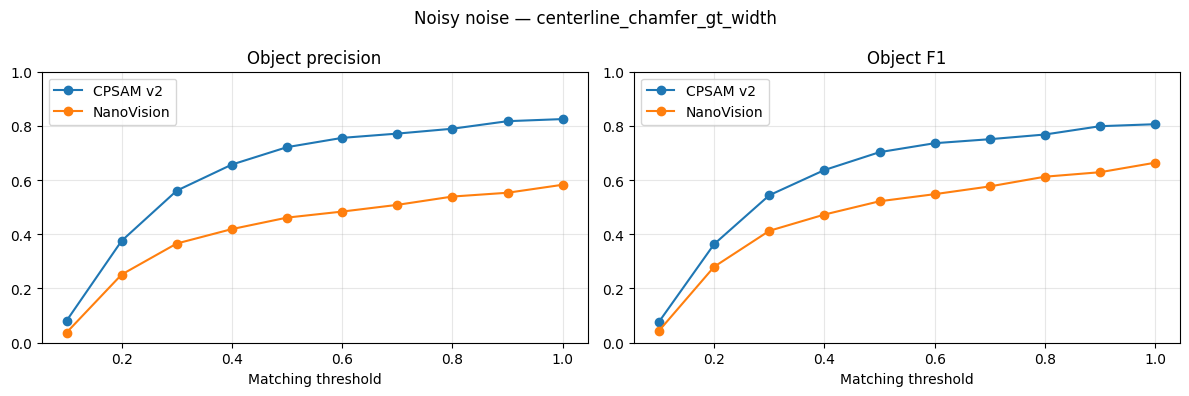

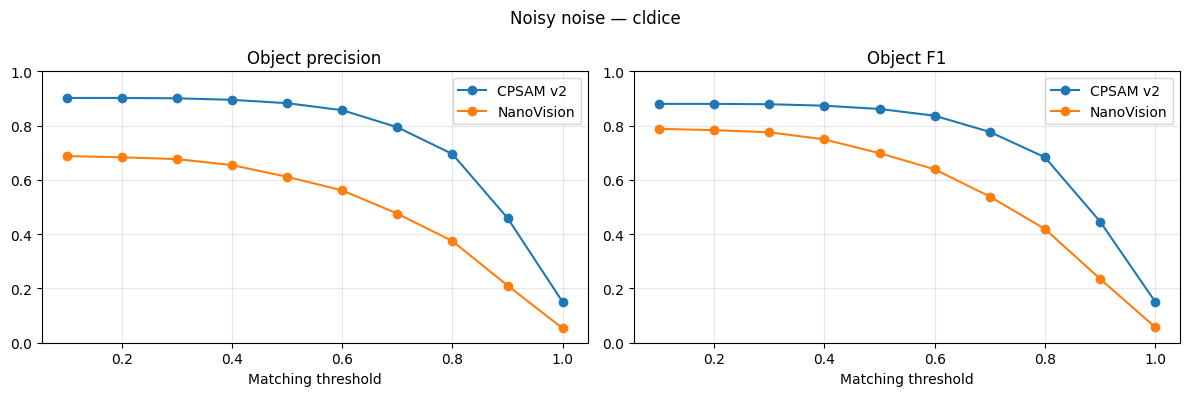

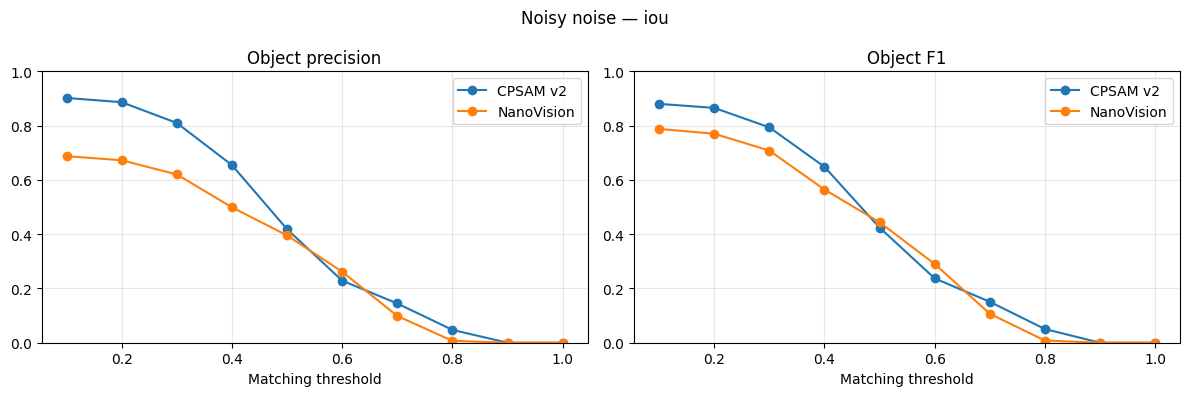

In [24]:
noise_class = "Noisy"

for matching_metric in (
    object_by_noise["matching_metric"].unique()
):
    subset = object_by_noise[
        (
            object_by_noise["noise_class"]
            == noise_class
        )
        & (
            object_by_noise["matching_metric"]
            == matching_metric
        )
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
    )

    for model, model_data in subset.groupby(
        "model"
    ):
        model_data = model_data.sort_values(
            "threshold"
        )

        axes[0].plot(
            model_data["threshold"],
            model_data["mean_precision"],
            marker="o",
            label=model,
        )

        axes[1].plot(
            model_data["threshold"],
            model_data["mean_f1"],
            marker="o",
            label=model,
        )

    axes[0].set_title("Object precision")
    axes[1].set_title("Object F1")

    for axis in axes:
        axis.set_xlabel("Matching threshold")
        axis.set_ylim(0.0, 1.0)
        axis.grid(
            alpha=0.3
        )
        axis.legend()

    fig.suptitle(
        f"{noise_class} noise — "
        f"{matching_metric}"
    )

    fig.tight_layout()
    plt.show()

# # Pixel metrics by density

In [25]:
pixel_by_density = (
    pixel_results.groupby(
        [
            "model",
            "density_class",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "filename",
            "nunique",
        ),
        pixel_precision=(
            "pixel_precision",
            "mean",
        ),
        pixel_recall=(
            "pixel_recall",
            "mean",
        ),
        pixel_f1=(
            "pixel_f1",
            "mean",
        ),
        pixel_iou=(
            "pixel_iou",
            "mean",
        ),
        pixel_dice=(
            "pixel_dice",
            "mean",
        ),
        pixel_cldice=(
            "pixel_cldice",
            "mean",
        ),
        pixel_fdr=(
            "pixel_fdr",
            "mean",
        ),
    )
)

display(pixel_by_density)

,model,density_class,number_of_images,pixel_precision,pixel_recall,pixel_f1,pixel_iou,pixel_dice,pixel_cldice,pixel_fdr
0,CPSAM v2,High,12,0.671721,0.899206,0.762765,0.623130,0.762765,0.891844,0.328279
1,CPSAM v2,Low,7,0.626393,0.901192,0.726741,0.580027,0.726741,0.887663,0.373607
2,CPSAM v2,Mid,11,0.490469,0.913933,0.634510,0.470317,0.634510,0.873190,0.509531
3,NanoVision,High,12,0.843593,0.753556,0.794993,0.662861,0.794993,0.886823,0.156407
4,NanoVision,Low,7,0.762980,0.768477,0.752069,0.605712,0.752069,0.895536,0.237020
5,NanoVision,Mid,11,0.709052,0.752893,0.721559,0.565637,0.721559,0.819695,0.290948


# # Pixel metrics by noise

In [26]:
pixel_by_noise = (
    pixel_results.groupby(
        [
            "model",
            "noise_class",
        ],
        as_index=False,
    )
    .agg(
        number_of_images=(
            "filename",
            "nunique",
        ),
        pixel_precision=(
            "pixel_precision",
            "mean",
        ),
        pixel_recall=(
            "pixel_recall",
            "mean",
        ),
        pixel_f1=(
            "pixel_f1",
            "mean",
        ),
        pixel_iou=(
            "pixel_iou",
            "mean",
        ),
        pixel_dice=(
            "pixel_dice",
            "mean",
        ),
        pixel_cldice=(
            "pixel_cldice",
            "mean",
        ),
        pixel_fdr=(
            "pixel_fdr",
            "mean",
        ),
    )
)

display(pixel_by_noise)

,model,noise_class,number_of_images,pixel_precision,pixel_recall,pixel_f1,pixel_iou,pixel_dice,pixel_cldice,pixel_fdr
0,CPSAM v2,Clean,20,0.614935,0.909857,0.723401,0.575204,0.723401,0.887303,0.385065
1,CPSAM v2,Noisy,10,0.554185,0.895494,0.675195,0.520716,0.675195,0.877480,0.445815
2,NanoVision,Clean,20,0.770343,0.790673,0.772561,0.633252,0.772561,0.884004,0.229657
3,NanoVision,Noisy,10,0.785670,0.689037,0.729033,0.575127,0.729033,0.824720,0.214330
